In [1]:
import pandas as pd 
import numpy as np

Insurance Cost Prediction using Machine Learning

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

Machine Learning models cannot understand words, so I converted text into numbers.  
sex: male → 1, female → 0  
smoker: yes → 1, no → 0  

region: used One-Hot Encoding to create 4 region columns

In [5]:
df['sex'] = df['sex'].apply(lambda x: 1 if x == 'male' else 0)
df['smoker'] = df['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

In [6]:
df = df.join(pd.get_dummies(df.region, dtype=int)).drop('region',axis=1)
df

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


I plotted histograms to understand the distribution of each feature such as age, BMI, children, and charges.

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'smoker'}>,
        <Axes: title={'center': 'charges'}>],
       [<Axes: title={'center': 'northeast'}>,
        <Axes: title={'center': 'northwest'}>,
        <Axes: title={'center': 'southeast'}>],
       [<Axes: title={'center': 'southwest'}>, <Axes: >, <Axes: >]],
      dtype=object)

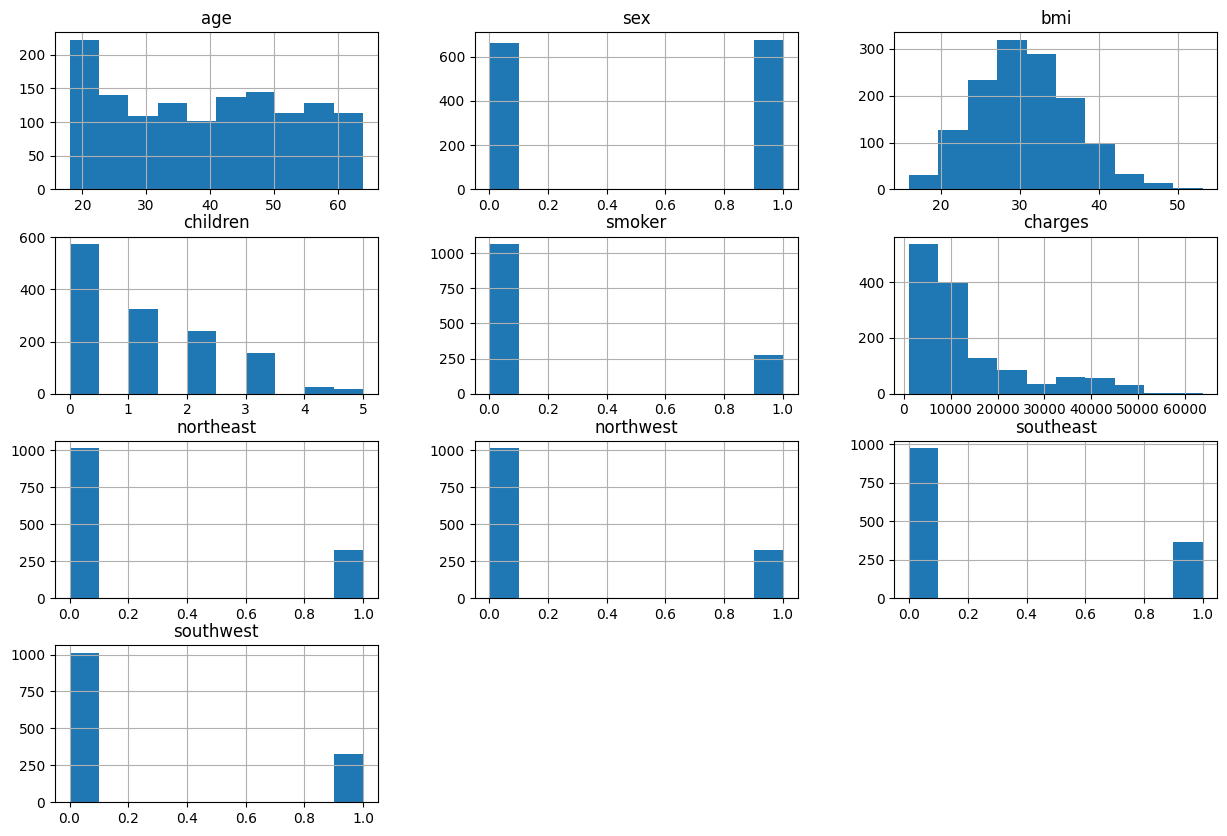

In [7]:
df.hist(figsize=(15,10))

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1338 non-null   int64  
 1   sex        1338 non-null   int64  
 2   bmi        1338 non-null   float64
 3   children   1338 non-null   int64  
 4   smoker     1338 non-null   int64  
 5   charges    1338 non-null   float64
 6   northeast  1338 non-null   int64  
 7   northwest  1338 non-null   int64  
 8   southeast  1338 non-null   int64  
 9   southwest  1338 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 104.7 KB


I created a correlation heatmap to check relationships between   features.   
For example:   
Smoker has the highest positive correlation with medical charges.   
BMI also has a moderate effect on charges.    

<Axes: >

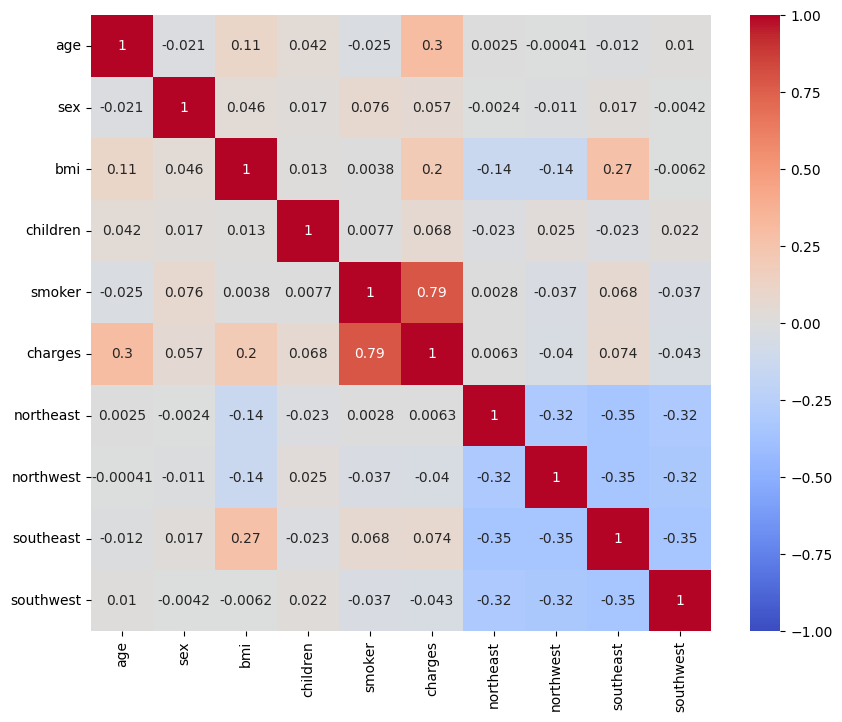

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',vmin=-1,vmax=1)

In [10]:
X = df.drop('charges', axis=1)
y = df['charges']

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

I used the Random Forest Regressor because it is strong, handles non-linear relationships, and reduces overfitting.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,r2_score

In [13]:
model = RandomForestRegressor(n_jobs=-1)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


n_jobs=-1 means it uses all CPU cores for faster training

In [14]:
y_pred = model.predict(X_test)

In [15]:
model.score(X_test,y_test)

0.8614367063450832

I evaluated the model using:

RMSE → error size

MAE → average absolute error

In [16]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

4638.078866432517

In [17]:
mae = mean_absolute_error(y_test,y_pred)
mae

2540.4099889938134

Text(0.5, 1.0, 'Prediction vs Truth')

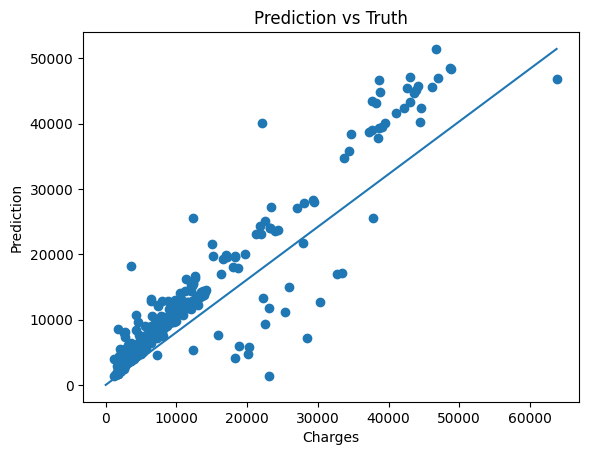

In [18]:
plt.scatter(y_test,y_pred)
plt.plot(np.linspace(0, max(y_test)), np.linspace(0, max(y_pred)))
plt.xlabel('Charges')
plt.ylabel('Prediction')
plt.title('Prediction vs Truth')

In [19]:
from sklearn.model_selection import GridSearchCV

I used GridSearchCV (Cross-Validation) to test all combinations of hyperparameters.
It selects the model with the best performance.

In [20]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=3,
                    n_jobs=-1,
                    verbose=2)


In [21]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [22]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [23]:
best_model = grid.best_estimator_

After tuning, the best version of the Random Forest model is selected and used for final prediction.
The tuned model usually performs better than the default model.

In [24]:
y_pred_tuned = best_model.predict(X_test)

In [25]:

print("Tuned RF R2:", r2_score(y_test, y_pred_tuned))
print("Tuned RF MAE:", mean_absolute_error(y_test, y_pred_tuned))

Tuned RF R2: 0.8768564707740758
Tuned RF MAE: 2516.4797255415638


In [26]:
import joblib

In [27]:
joblib.dump(best_model, "insurance_model.pkl")


['insurance_model.pkl']

In this project, I built a machine learning model to predict medical insurance charges. I cleaned the data, converted categorical values into numbers, and performed visual analysis using histograms and a correlation heatmap. I trained a Random Forest model, evaluated its accuracy, and then improved it using GridSearchCV hyperparameter tuning. The final optimized model was saved as insurance_model.pkl for future use in predicting insurance costs.